# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import classification_report

from imblearn.over_sampling import  ADASYN

In [2]:
random_state = 150

# Load Dataset

In [3]:
df = pd.read_csv('./Dataset/data_1D.csv')
df.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,0,83,retired,divorced,basic.4y,no,no,no,cellular,nov,tue,242.0,1,3,3,success,yes
1,1,32,services,married,high.school,no,no,no,telephone,may,tue,190.0,3,999,0,nonexistent,no
2,2,31,admin.,single,university.degree,no,yes,no,telephone,may,wed,325.0,2,999,0,nonexistent,no
3,3,33,admin.,single,university.degree,no,yes,no,telephone,aug,thu,158.0,1,999,0,nonexistent,no
4,4,39,services,married,high.school,no,yes,no,telephone,jul,mon,158.0,1,999,0,nonexistent,no


## Filter the dataset to only include the columns we need

Filtered Columns:
- Unnamed: 0 -> ID columns

In [4]:
df.drop('Unnamed: 0', axis=1, inplace=True)

# EDA (Exploratory Data Analysis)

## Data Description

### Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8238 entries, 0 to 8237
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8238 non-null   int64  
 1   job          8230 non-null   object 
 2   marital      8238 non-null   object 
 3   education    8238 non-null   object 
 4   default      8238 non-null   object 
 5   housing      8238 non-null   object 
 6   loan         8238 non-null   object 
 7   contact      8238 non-null   object 
 8   month        8238 non-null   object 
 9   day_of_week  8238 non-null   object 
 10  duration     8226 non-null   float64
 11  campaign     8238 non-null   int64  
 12  pdays        8238 non-null   int64  
 13  previous     8238 non-null   int64  
 14  poutcome     8238 non-null   object 
 15  y            8238 non-null   object 
dtypes: float64(1), int64(4), object(11)
memory usage: 1.0+ MB


All of the types seems to be correct.

### Basic Statistics

In [6]:
df.describe()

,age,duration,campaign,pdays,previous
count,8238.000000,8226.000000,8238.000000,8238.000000,8238.000000
mean,39.928866,258.179066,2.565429,963.904831,0.169701
std,10.512521,266.734969,2.792797,183.413644,0.492601
min,17.000000,4.000000,1.000000,0.000000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.750000,3.000000,999.000000,0.000000
max,89.000000,4918.000000,43.000000,999.000000,6.000000


The data seems to somewhat normal apart from `previous` column and `pdays` seems to have some extreme values. but we will look into it later.

### Numerical Correlation

<Axes: >

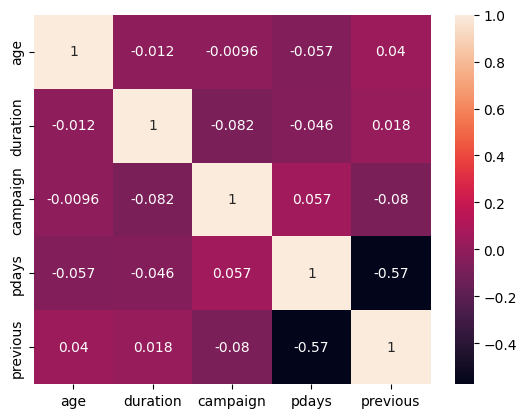

In [7]:
numeric_features = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_features.corr(), annot=True)

`pdays` and `previous` seems to have some correlation. We will drop `pdays` column as it can cause multicollinearity.

## Missing Values

In [8]:
df.isnull().sum()

age             0
job             8
marital         0
education       0
default         0
housing         0
loan            0
contact         0
month           0
day_of_week     0
duration       12
campaign        0
pdays           0
previous        0
poutcome        0
y               0
dtype: int64

There are some missing values in `job` and `duration` columns. We will impute them with the mode and mean respectively.

## Distribution

### Numerical Columns

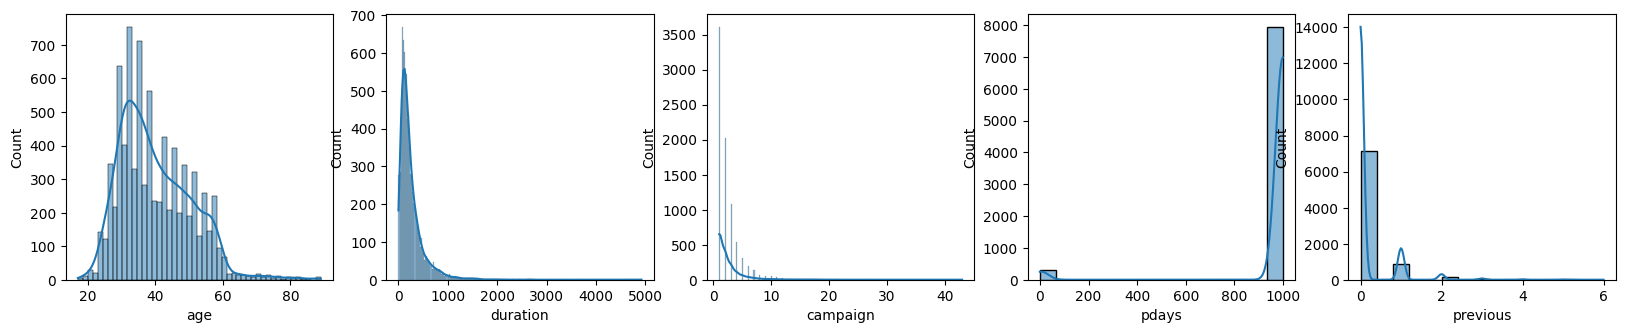

In [9]:
numeric_features = df.select_dtypes(include=[np.number])

fig = plt.figure(figsize=(20, 20))
for i in range(len(numeric_features.columns)):
    fig.add_subplot(5, 5, i+1)
    sns.histplot(numeric_features.iloc[:, i].dropna(), kde=True)
    plt.xlabel(numeric_features.columns[i])

- `age` seems to be normally distributed.
- `duration` seems to be right skewed.
- `campaign` seems to be right skewed.
- `pdays` seems to be left skewed.
- `previous` seems to be right skewed.

we will need to do some scaling on the data.

### Categorical Columns

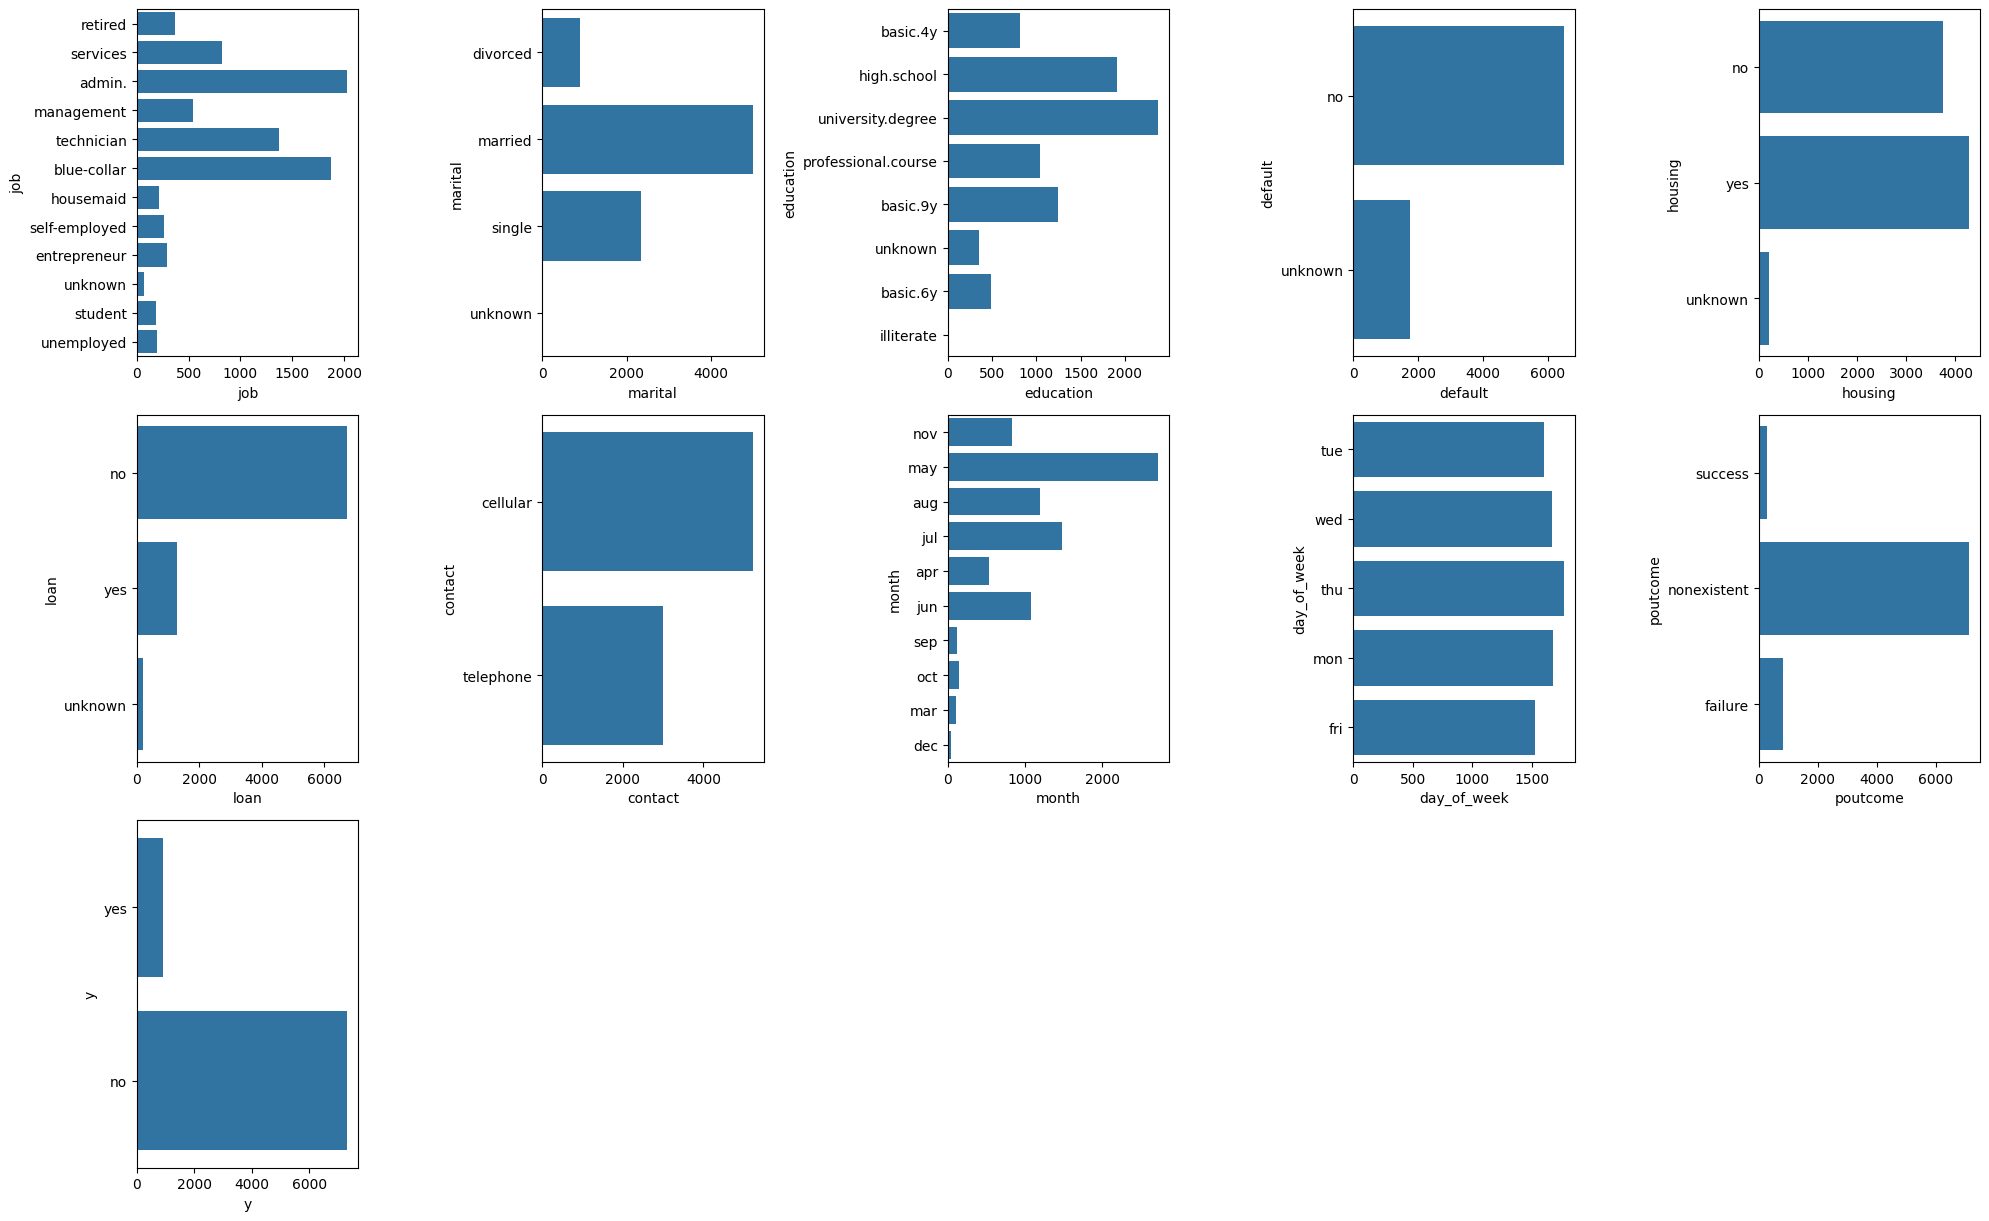

In [10]:
fig = plt.figure(figsize=(20, 20))

category_features = df.select_dtypes(include=[object])

for i in range(len(category_features.columns)):
    fig.add_subplot(5, 5, i+1)
    sns.countplot(category_features.iloc[:, i].dropna())
    plt.xlabel(category_features.columns[i])

plt.tight_layout()
plt.show()

Features found :
- Data is imbalanced -> Appy ADASYN
- `unknown` values in some columns -> treat as a feature

# Data Preprocessing

## Drop Columns (multicollinearity)

In [11]:
df.drop('pdays', axis=1, inplace=True)

## Train Test Split

In [12]:
X, y = df.drop('y', axis=1), df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

## Impute Missing Values

In [13]:
X_train.fillna({'job': X_train['job'].mode()[0], 'duration': X_train['duration'].mean()}, inplace=True)

In [14]:
X_test.fillna({'job': X_test['job'].mode()[0], 'duration': X_test['duration'].mean()}, inplace=True)

## Scaling

In [15]:
numeric_features = X_train.select_dtypes(include=[np.number])

scaler = StandardScaler(with_std=True, with_mean=True)

X_train[numeric_features.columns] = scaler.fit_transform(X_train[numeric_features.columns])
X_test[numeric_features.columns] = scaler.transform(X_test[numeric_features.columns])

## Encoding

In [16]:
category_features = X_train.select_dtypes(include=[object])

encoder = OrdinalEncoder()

X_train[category_features.columns] = encoder.fit_transform(X_train[category_features.columns])
X_test[category_features.columns] = encoder.transform(X_test[category_features.columns])

## ADASYN

In [22]:
over_sampler = ADASYN(random_state=random_state)

X_train, y_train = over_sampler.fit_resample(X_train, y_train)

# Model Selection

## Decision Tree

In [23]:
dt_tree = DecisionTreeClassifier(random_state=random_state)

dt_tree.fit(X_train, y_train)

y_pred = dt_tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.93      0.90      0.92      1472
         yes       0.35      0.44      0.39       176

    accuracy                           0.85      1648
   macro avg       0.64      0.67      0.65      1648
weighted avg       0.87      0.85      0.86      1648



## KNN

In [24]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.95      0.83      0.89      1472
         yes       0.31      0.65      0.42       176

    accuracy                           0.81      1648
   macro avg       0.63      0.74      0.65      1648
weighted avg       0.88      0.81      0.84      1648



## Random Forest

In [29]:
random_forest = RandomForestClassifier(random_state=random_state)

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.94      0.96      0.95      1472
         yes       0.59      0.49      0.54       176

    accuracy                           0.91      1648
   macro avg       0.77      0.72      0.74      1648
weighted avg       0.90      0.91      0.91      1648



# Conclusion

The best model is Random Forest with 59 precision on the positive values. We chose precision as the metric because we want to minimize the false positive values because false positive will result in loss for the bank. THus although Random Forest algorithm is not easily interpretable, it is the best model for this dataset.

# Save Model

In [31]:
model = random_forest
scaler = scaler
encoder = encoder

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)